## Aim of the Project

### The primary aim of this project is to analyze employee data at INX Future Inc. to identify the root causes behind declining performance and reduced client satisfaction. The project also aims to:

### Evaluate department-wise performance

### Identify key factors affecting employee performance

### Build a predictive model for employee performance

### Provide data-driven recommendations to improve overall performance without negatively impacting employee morale

In [1]:
import pandas as pd # importing Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pip install pandas xlrd  # installing pandas xlrd used to enable  reading and processing of data from Excel spreadsheet files. 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [3]:
df_xls=pd.read_excel(r"C:\Users\rohit\Desktop\Datamites Data\IABAC project\IABA project.xls")  # reading excel file from designated location

In [4]:
df_xls.to_csv("IABAC.csv", index=None, header=True) # converting excel file into CSV
df = pd.DataFrame(pd.read_csv("IABAC.csv")) # making dataframe of csv file
df.head()  # visualizing data

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [5]:
df.info()  # checking columns, datatype and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [6]:
df.isnull().sum() # checking null values columnwise

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [7]:
df.describe() #checking various parameters of numerical columns in dataframe

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [8]:
df.describe(include=object) #checking various parameters of non-numerical columns in dataframe

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E100967,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


In [9]:
df[df.duplicated()] # checking duplicate values to find them and delete

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


In [10]:
for col in df.describe().columns: # checking unique values in each columns and found that no outlier is present
    print(col)
    print(df[col].unique())
    print('-'*50)

Age
[32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]
--------------------------------------------------
DistanceFromHome
[10 14  5 16  8  1 24  3 27 19  9  2  7  6 26 11 23 13 29 12  4 25 21 18
 20 17 22 28 15]
--------------------------------------------------
EmpEducationLevel
[3 4 2 5 1]
--------------------------------------------------
EmpEnvironmentSatisfaction
[4 2 1 3]
--------------------------------------------------
EmpHourlyRate
[ 55  42  48  73  84  32  54  67  63  81  49  99  57  96  44  86  83  61
  80  31  46  79  77  60  76  41  71  66  38  72  95  82  75  93  64  36
  69  33  35  40  43  51  52  98  45  37  94  59  88  50  65  53  56  78
  74  91  62  87  68  34  70 100  92  39  97  47  90  85  30  58  89]
--------------------------------------------------
EmpJobInvolvement
[3 2 1 4]
--------------------------------------------------
EmpJobLevel
[2 3 5 1 4]
-----------------------------

In [11]:
df['Gender'].value_counts() # checking unique values with their counts.

Gender
Male      725
Female    475
Name: count, dtype: int64

In [12]:
df['EducationBackground'].value_counts() # checking unique values with their counts.

EducationBackground
Life Sciences       492
Medical             384
Marketing           137
Technical Degree    100
Other                66
Human Resources      21
Name: count, dtype: int64

In [13]:
df['EducationBackground']=df['EducationBackground'].str.replace('Human Resources','EB Human Resources') #changing data as multiple times Human Resources string is present in various columns
df['EducationBackground'].value_counts()

EducationBackground
Life Sciences         492
Medical               384
Marketing             137
Technical Degree      100
Other                  66
EB Human Resources     21
Name: count, dtype: int64

In [14]:
df['MaritalStatus'].value_counts() # checking unique values with their counts.

MaritalStatus
Married     548
Single      384
Divorced    268
Name: count, dtype: int64

In [15]:
df['EmpDepartment'].value_counts() # checking unique values with their counts.

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [16]:
df['EmpDepartment']=df['EmpDepartment'].str.replace('Human Resources','ED Human Resources')  #changing data as multiple times Human Resources string is present in various columns
df['EmpDepartment'].value_counts()

EmpDepartment
Sales                     373
Development               361
Research & Development    343
ED Human Resources         54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [17]:
df['EmpJobRole'].value_counts() # checking unique values with their counts.

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
Human Resources               45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
Name: count, dtype: int64

In [18]:
df['EmpJobRole']=df['EmpJobRole'].str.replace('Human Resources','EJ Human Resources')  #changing data as multiple times Human Resources string is present in various columns
df['EmpJobRole'].value_counts()

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
EJ Human Resources            45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
Name: count, dtype: int64

In [19]:
df['BusinessTravelFrequency'].value_counts() # checking unique values with their counts.

BusinessTravelFrequency
Travel_Rarely        846
Travel_Frequently    222
Non-Travel           132
Name: count, dtype: int64

In [20]:
df['OverTime'].value_counts() # checking unique values with their counts.

OverTime
No     847
Yes    353
Name: count, dtype: int64

In [21]:
df['OverTime']=df['OverTime'].str.replace('No','OT_no') # #changing data as multiple times Yes/No string is present in various columns
df['OverTime']=df['OverTime'].str.replace('Yes','OT_yes')
df['OverTime'].value_counts()

OverTime
OT_no     847
OT_yes    353
Name: count, dtype: int64

In [22]:
df['Attrition'].value_counts()                    

Attrition
No     1022
Yes     178
Name: count, dtype: int64

In [23]:
df['Attrition']=df['Attrition'].str.replace('No','Attrition_no') #changing data as multiple times Yes/No string is present in various columns
df['Attrition']=df['Attrition'].str.replace('Yes','Attrition_yes')
df['Attrition'].value_counts() 

Attrition
Attrition_no     1022
Attrition_yes     178
Name: count, dtype: int64

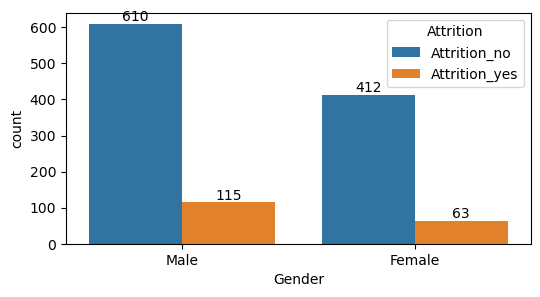

In [24]:
plt.figure(figsize=(6,3)) # Visualizing the relationship between Gender and attrition rate shows male attrition percentage is approximately similar with female attrition percentage and can be ignored.
axg=sns.countplot(x=df['Gender'],hue=df['Attrition'])
for bars in axg.containers:
    axg.bar_label(bars)

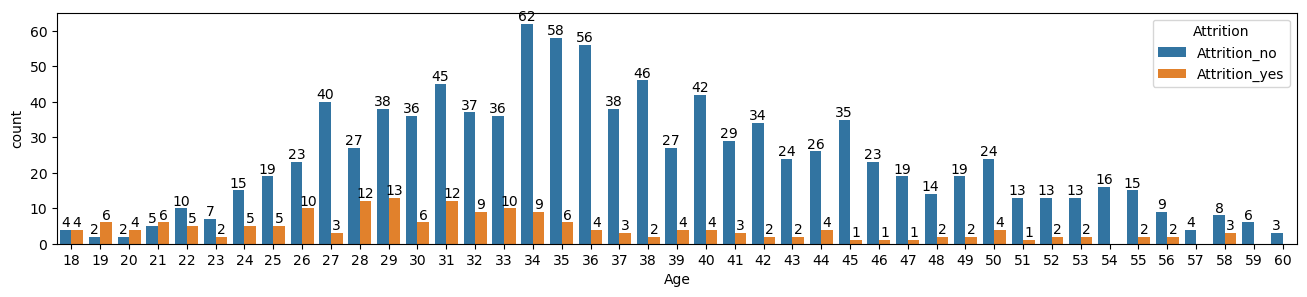

In [25]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between age and attrition rate shows employees between age 18 to 33 have high attrition rate.
axa=sns.countplot(x=df['Age'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

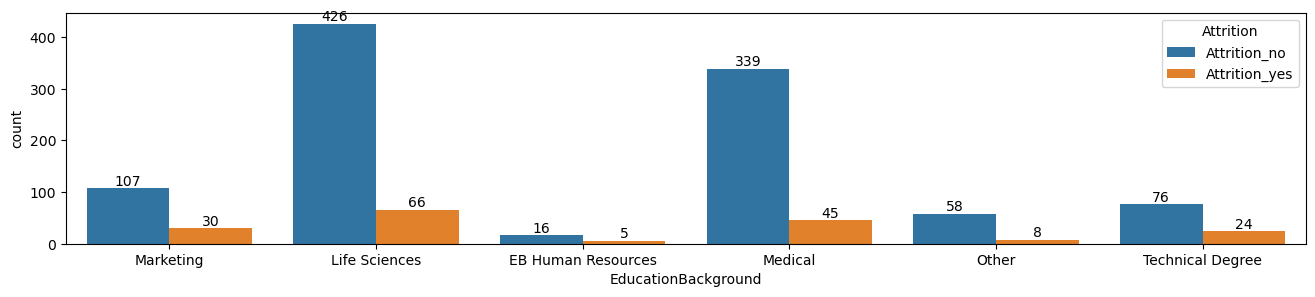

In [26]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Educational Background and attrition rate shows employees from marketing, HR and technical degree have high attrition rate.
axa=sns.countplot(x=df['EducationBackground'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

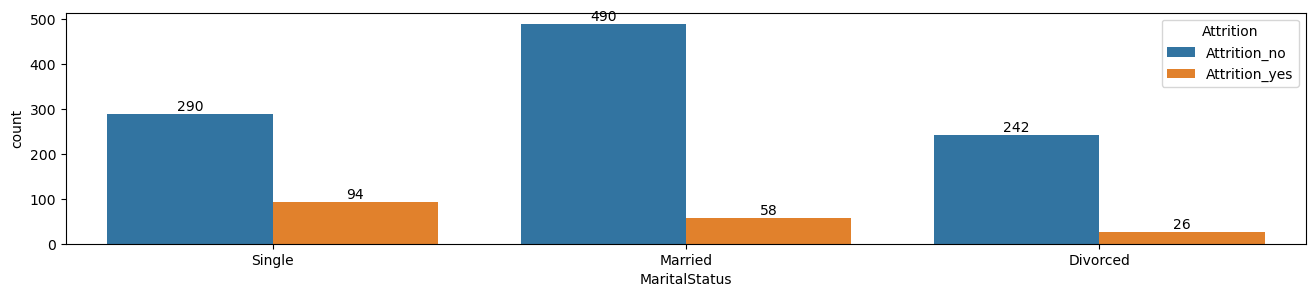

In [27]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Marital Status and attrition rate shows single employeee have high attrition rate.
axa=sns.countplot(x=df['MaritalStatus'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

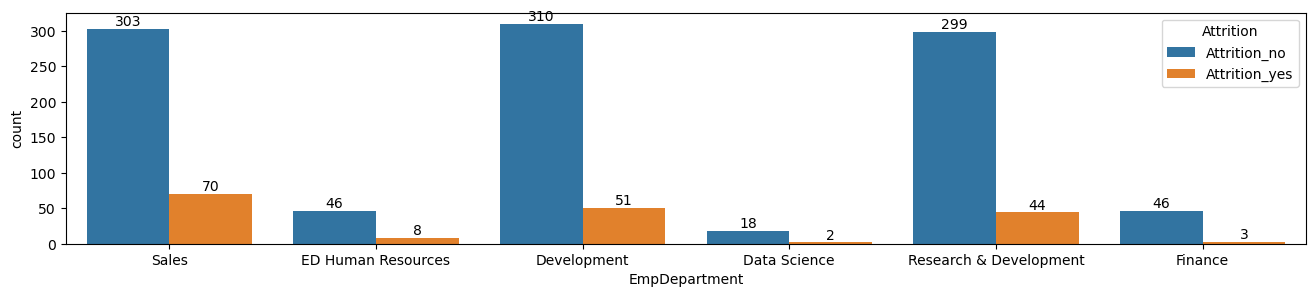

In [28]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Employee Department and attrition rate shows employees from sales department have high attrition rate.
axa=sns.countplot(x=df['EmpDepartment'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

In [29]:
df['EmpJobRole'].value_counts()

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
EJ Human Resources            45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
Name: count, dtype: int64

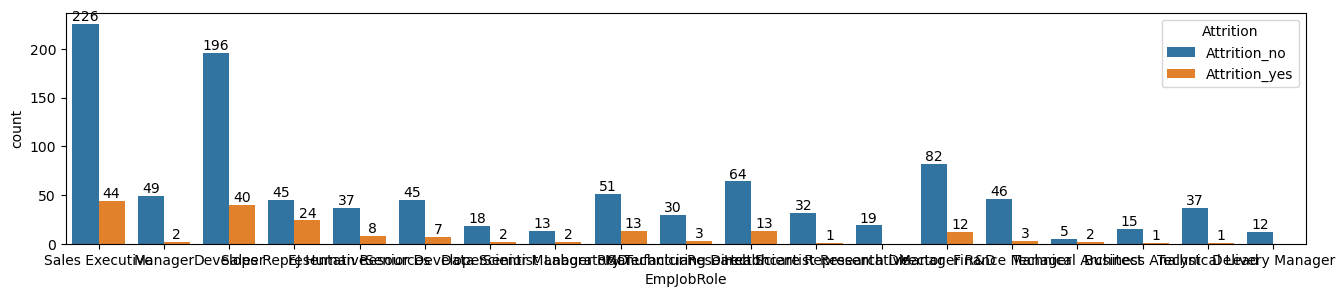

In [30]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Employee Job Role and attrition rate shows employees with job role as Sales Executive,developer,Sales Representative, HR, Laboratory Technician and Research Scientist have high attrition rate.
axa=sns.countplot(x=df['EmpJobRole'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

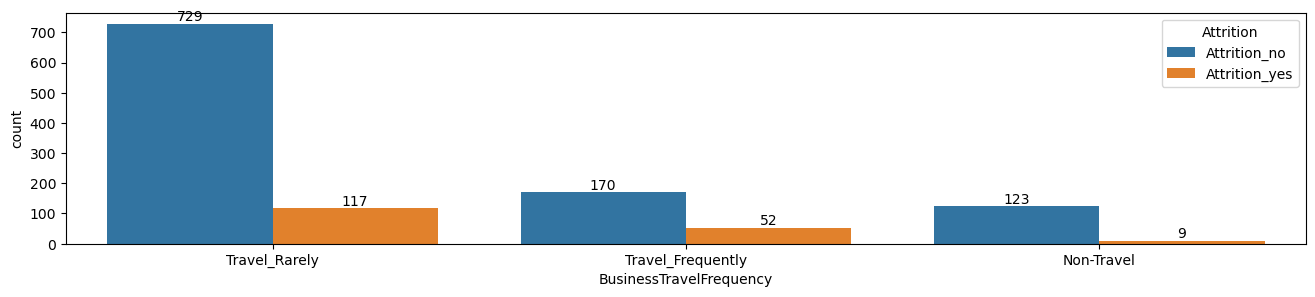

In [31]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Business Travel Frequency and attrition rate shows employees who travel frequently have high attrition rate.
axa=sns.countplot(x=df['BusinessTravelFrequency'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

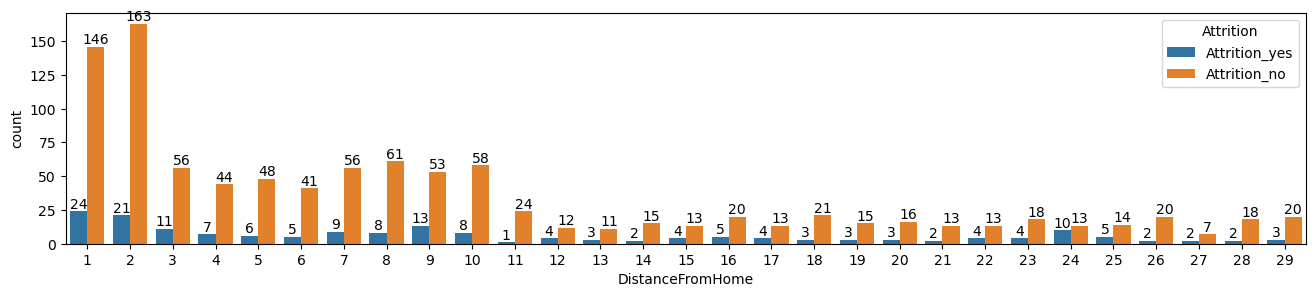

In [32]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Distance From Home and attrition rate do not show any specific impact on attrition rate.
axa=sns.countplot(x=df['DistanceFromHome'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

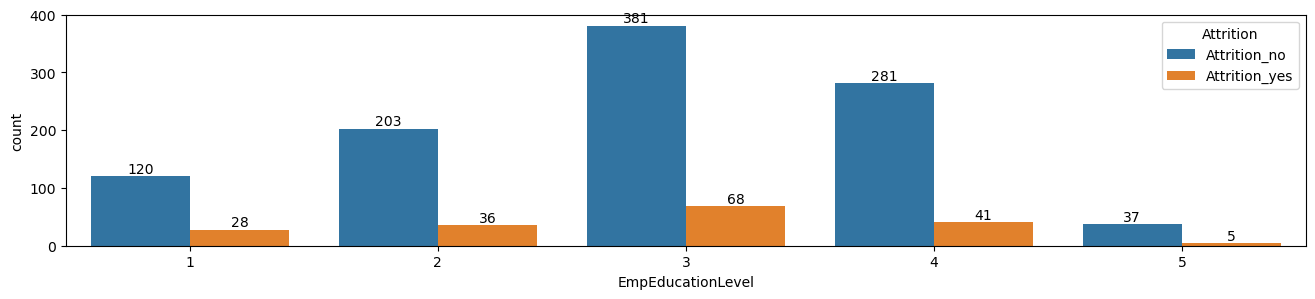

In [33]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Education Level and attrition rate shows employees whose eduction level is below college have high attrition rate.
axa=sns.countplot(x=df['EmpEducationLevel'],hue=df['Attrition']) # 1='Below College', 2 ='College', 3='Bachelor', 4='Master', 5='Doctor'
for bars in axa.containers:
    axa.bar_label(bars)

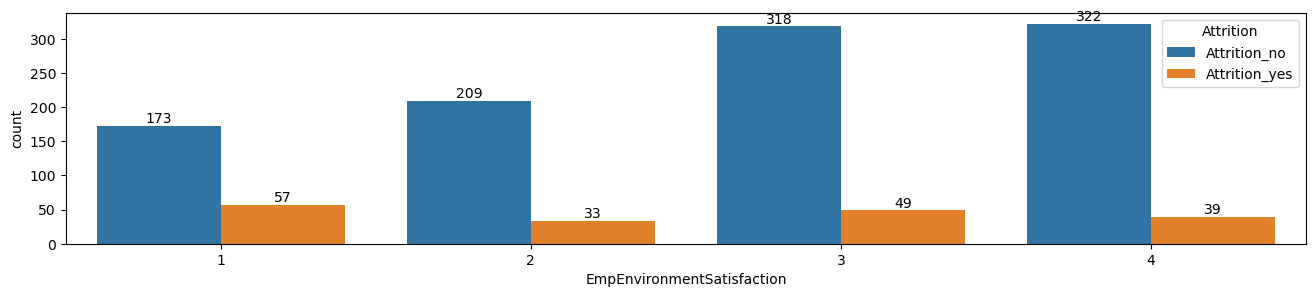

In [34]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Environment Satisfaction and attrition rate shows employees who are less satisfied have high attrition rate.
axa=sns.countplot(x=df['EmpEnvironmentSatisfaction'],hue=df['Attrition'])  # 1='Low', 2='Medium', 3='High', 4='Very High'
for bars in axa.containers:
    axa.bar_label(bars)

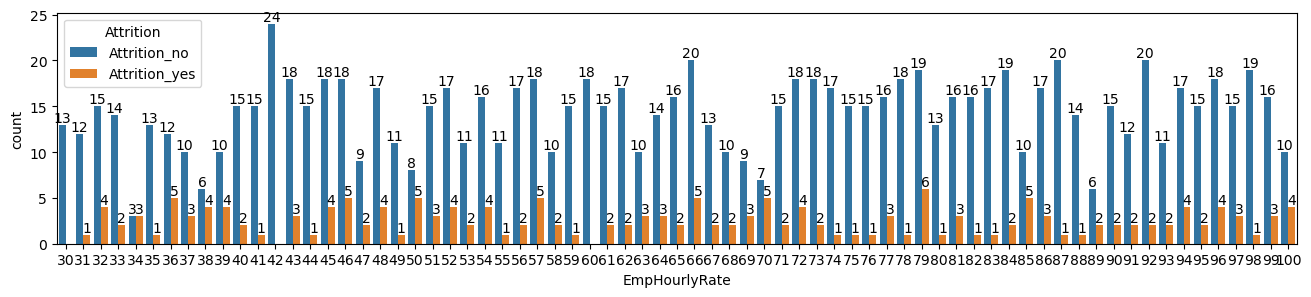

In [35]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Hourly Rate and attrition do not show much impact on attrition rate.
axa=sns.countplot(x=df['EmpHourlyRate'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

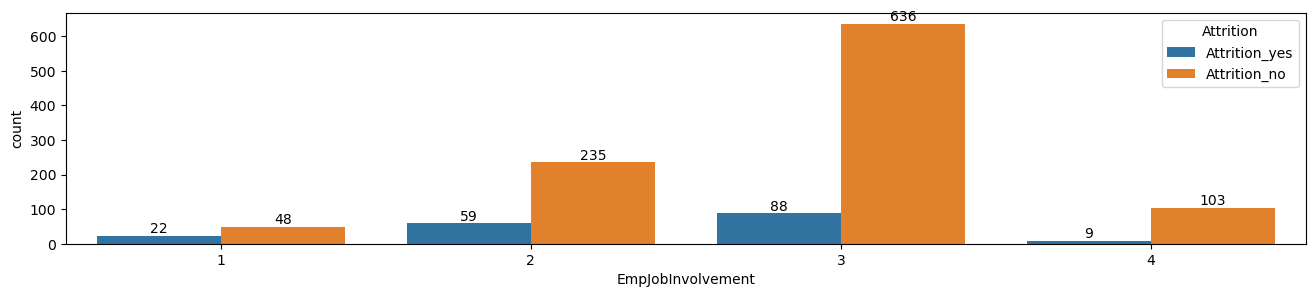

In [36]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Job Involvement and attrition rate shows employees with less involvement have high attrition rate. 
axa=sns.countplot(x=df['EmpJobInvolvement'],hue=df['Attrition'])  # 1='Low', 2='Medium', 3='High', 4='Very High'
for bars in axa.containers:
    axa.bar_label(bars)

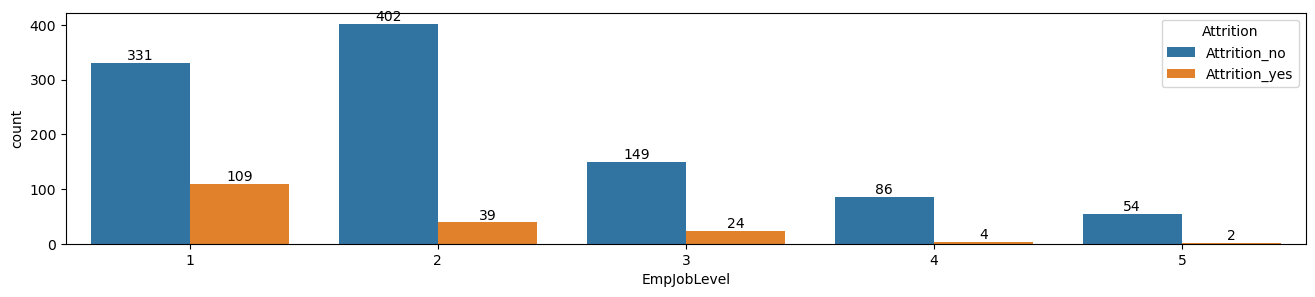

In [37]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Job Level and attrition rate shows employees with low job level have high attrition rate. 
axa=sns.countplot(x=df['EmpJobLevel'],hue=df['Attrition'])  # 1='Low', 2='Medium', 3='High', 4='Very High', 5='extreme high'
for bars in axa.containers:
    axa.bar_label(bars)

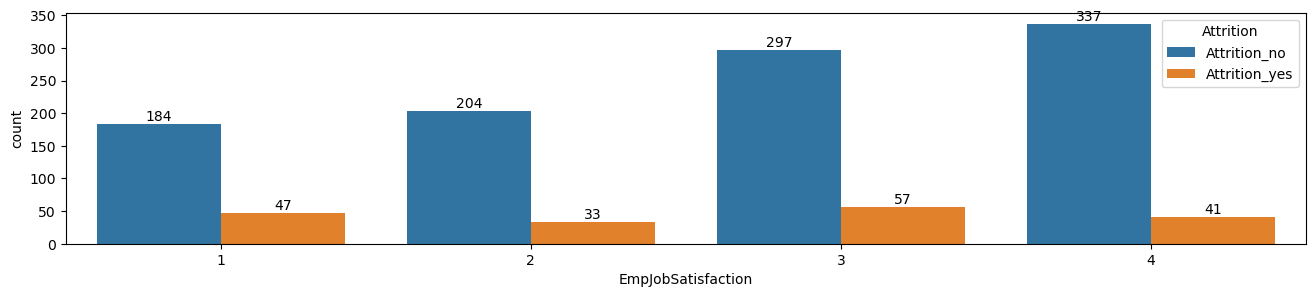

In [38]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Job satisfaction and attrition rate shows employees with less job satisfaction have high attrition rate. 
axa=sns.countplot(x=df['EmpJobSatisfaction'],hue=df['Attrition'])  # 1='Low', 2='Medium', 3='High', 4='Very High'
for bars in axa.containers:
    axa.bar_label(bars)

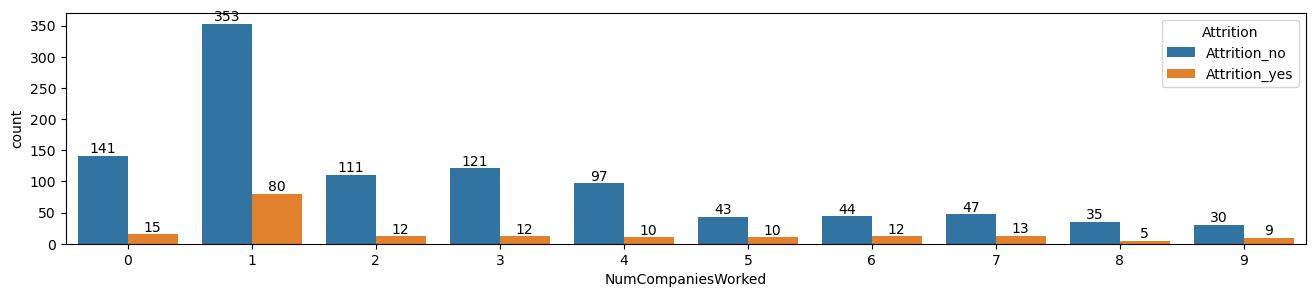

In [39]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Number of Companies Worked and attrition rate shows employees who worked in 1 or more than 5 companies have high attrition rate. 
axa=sns.countplot(x=df['NumCompaniesWorked'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

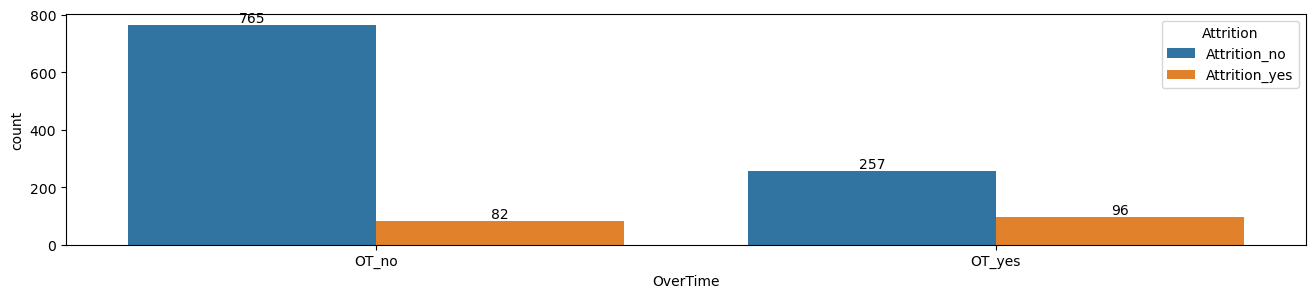

In [40]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between OverTime and attrition rate shows employees who do overtime have high attrition rate.
axa=sns.countplot(x=df['OverTime'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

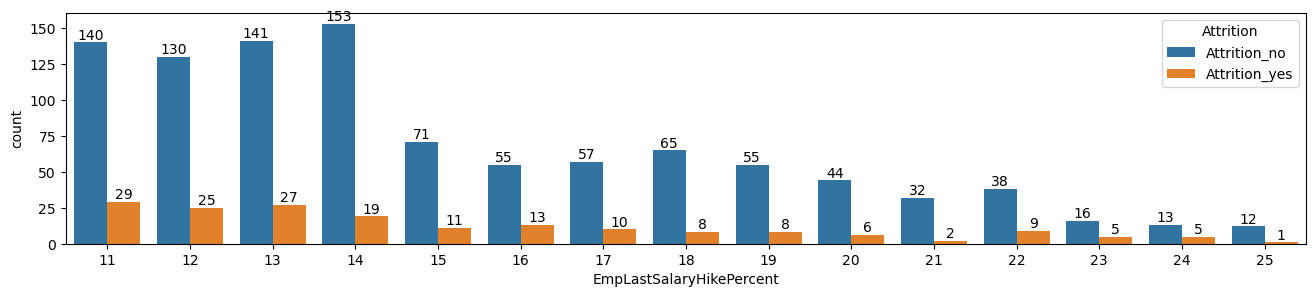

In [41]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Last Salary Hike Percent and attrition rate shows employees with less salary hike have high attrition rate.
axa=sns.countplot(x=df['EmpLastSalaryHikePercent'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

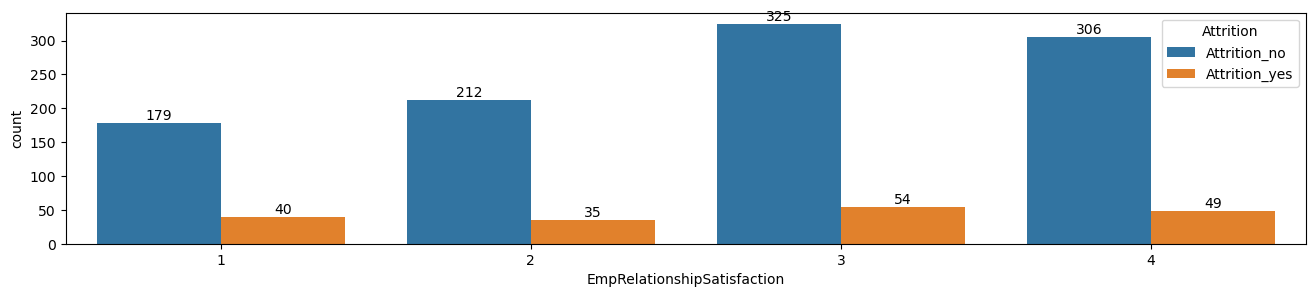

In [42]:
plt.figure(figsize=(16,3))  # Visualizing the relationship between Relationship Satisfaction and attrition rate shows employees with less satisfaction have high attrition rate.
axa=sns.countplot(x=df['EmpRelationshipSatisfaction'],hue=df['Attrition'])  # 1='Low', 2='Medium', 3='High', 4='Very High'
for bars in axa.containers:
    axa.bar_label(bars)

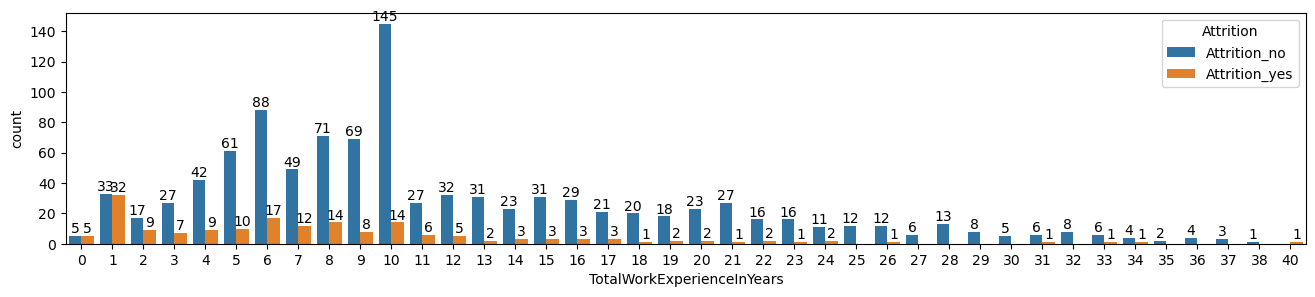

In [43]:
plt.figure(figsize=(16,3))  # Visualizing the relationship between Total Work Experience In Years and attrition rate shows employees with less Work Experience have high attrition rate.
axa=sns.countplot(x=df['TotalWorkExperienceInYears'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

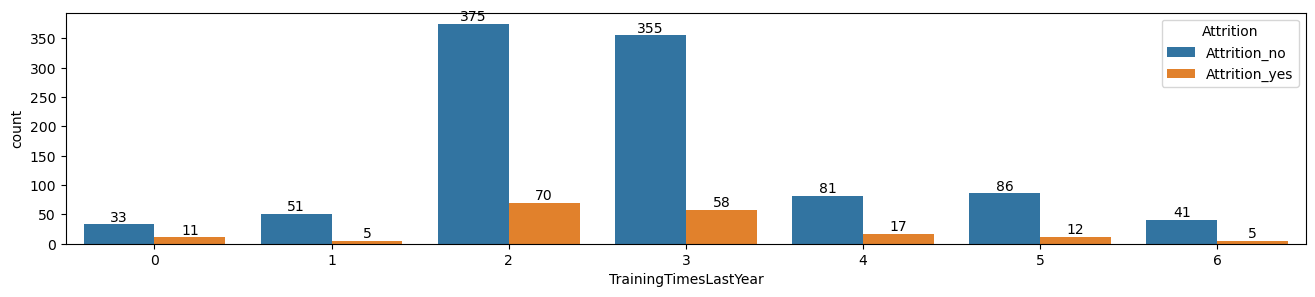

In [44]:
plt.figure(figsize=(16,3))  # Visualizing the relationship between Training Times Last Year and attrition rate shows employees with no Training have high attrition rate.
axa=sns.countplot(x=df['TrainingTimesLastYear'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

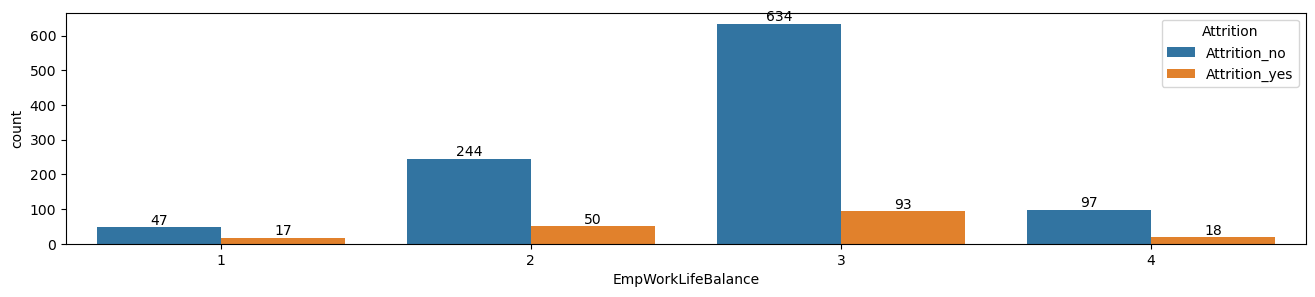

In [45]:
plt.figure(figsize=(16,3))   # Visualizing the relationship between Work Life Balance and attrition rate shows employees with less Work Life Balance have high attrition rate.
axa=sns.countplot(x=df['EmpWorkLifeBalance'],hue=df['Attrition']) # 1='Bad', 2='Good', 3='Better', 4='Best'
for bars in axa.containers:
    axa.bar_label(bars)

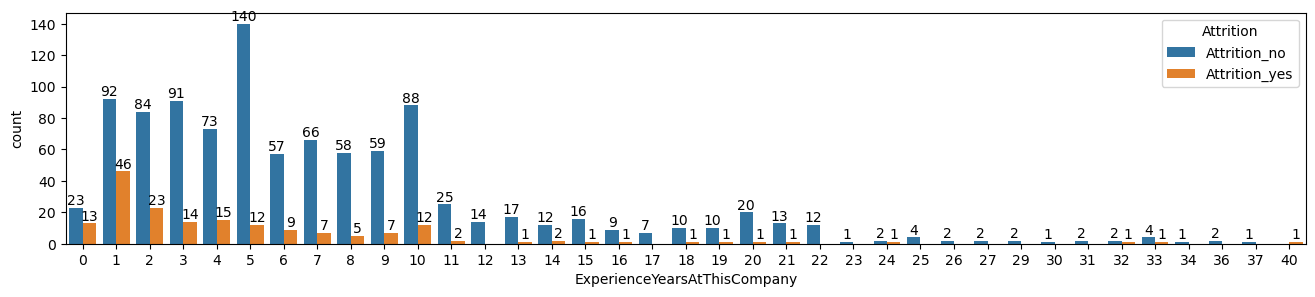

In [46]:
plt.figure(figsize=(16,3))  # Visualizing the relationship between Experience Years At This Company and attrition rate shows employees with less experience have high attrition rate.
axa=sns.countplot(x=df['ExperienceYearsAtThisCompany'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

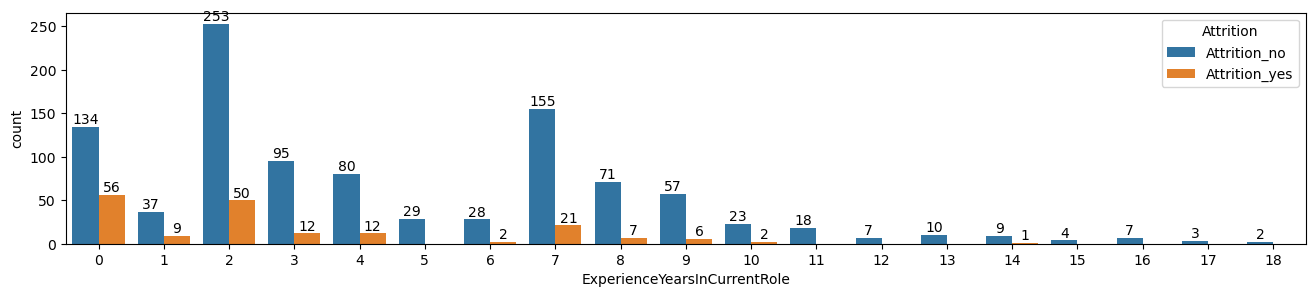

In [47]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Experience Years In Current Role and attrition rate shows employees with less experience have high attrition rate.
axa=sns.countplot(x=df['ExperienceYearsInCurrentRole'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

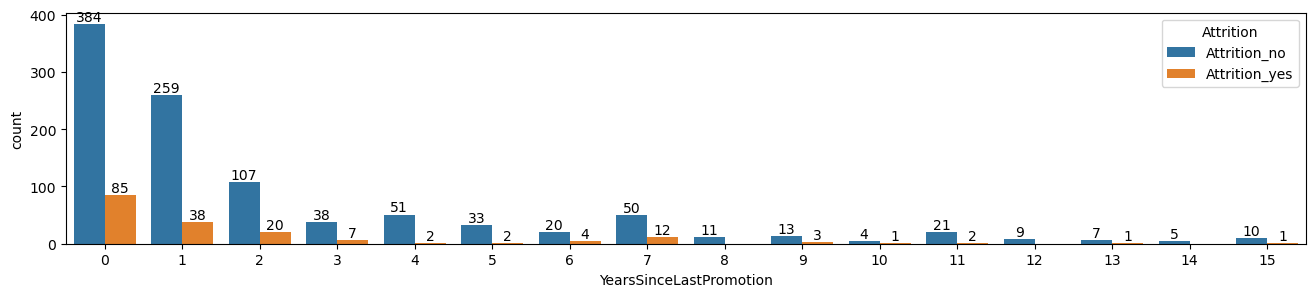

In [48]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Years Since Last Promotion and attrition rate shows employees left within 1  to 2 years after promotion
axa=sns.countplot(x=df['YearsSinceLastPromotion'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

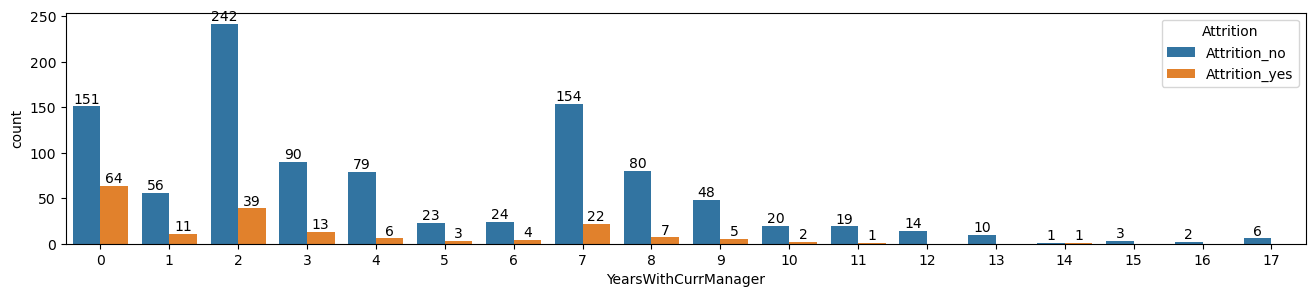

In [49]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Years With Current Manager and attrition rate shows employees with less year have high attrition rate.
axa=sns.countplot(x=df['YearsWithCurrManager'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

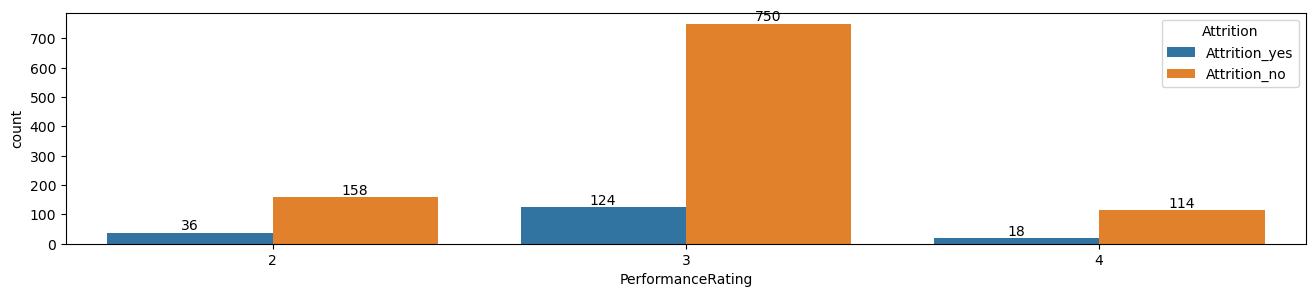

In [50]:
plt.figure(figsize=(16,3)) # Visualizing the relationship between Performance Rating and attrition rate shows employees with rating of 3 have high attrition rate.
axa=sns.countplot(x=df['PerformanceRating'],hue=df['Attrition'])
for bars in axa.containers:
    axa.bar_label(bars)

## After all the feature visual analysis, the following three factors were identified as the most significant drivers of performance:

### Employee Environment Satisfaction: The physical and cultural work environment is the single largest predictor of performance.

### Employee Last Salary Hike Percent : Financial incentives and the percentage of salary hike strongly correlate with high performance ratings.

### Years Since Last Promotion : Stagnation in a role leads to lower performance; employees who have been promoted more recently or are on a clear growth path perform better.

In [51]:
df.groupby(['EmpDepartment'])['PerformanceRating'].mean() 

EmpDepartment
Data Science              3.050000
Development               3.085873
ED Human Resources        2.925926
Finance                   2.775510
Research & Development    2.921283
Sales                     2.860590
Name: PerformanceRating, dtype: float64

### The analysis of performance across various departments reveals that Development and Data Science departments consistently achieve the highest average ratings, while Finance and Sales show room for improvement.

## Visualization completed

In [52]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,Attrition_no,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,Attrition_no,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,Attrition_no,4
3,E1001009,41,Male,EB Human Resources,Divorced,ED Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,Attrition_no,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,Attrition_no,3


## Data Preprocessing

### Handle missing values

### Remove duplicates

### Using One Hot Encoding method to encode Categorical Variables as Machine learning models require numerical input.

In [53]:
genders=pd.get_dummies(df['Gender']) #Encoding Categorical Variables as Machine learning models require numerical input.
EduB=pd.get_dummies(df['EducationBackground'],dtype='int')
MarS=pd.get_dummies(df['MaritalStatus'],dtype='int')
EmpD=pd.get_dummies(df['EmpDepartment'],dtype='int')
EmpJR=pd.get_dummies(df['EmpJobRole'],dtype='int')
BussTF=pd.get_dummies(df['BusinessTravelFrequency'],dtype='int')
OverT=pd.get_dummies(df['OverTime'],dtype='int')
Attritions=pd.get_dummies(df['Attrition'],dtype='int')

In [54]:
df=pd.concat([df,genders],axis=1) #the One_hot_encoded columns are concatenated with the original dataeset.
df=pd.concat([df,EduB],axis=1)
df=pd.concat([df,MarS],axis=1)
df=pd.concat([df,EmpD],axis=1)
df=pd.concat([df,EmpJR],axis=1)
df=pd.concat([df,BussTF],axis=1)
df=pd.concat([df,OverT],axis=1)
df=pd.concat([df,Attritions],axis=1)
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,Senior Manager R&D,Technical Architect,Technical Lead,Non-Travel,Travel_Frequently,Travel_Rarely,OT_no,OT_yes,Attrition_no,Attrition_yes
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,0,0,0,0,0,1,1,0,1,0
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,0,0,0,0,0,1,1,0,1,0
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,0,0,0,0,1,0,0,1,1,0
3,E1001009,41,Male,EB Human Resources,Divorced,ED Human Resources,Manager,Travel_Rarely,10,4,...,0,0,0,0,0,1,1,0,1,0
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,0,0,0,0,0,1,1,0,1,0


In [55]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating', 'Female',
       'Male', 'EB Human Resources', 'Life Sciences', 'Marketing', 'Medical',
       'Other', 'Technical Degree', 'Divorced', 'Married', 'Single',
       'Data Science', 'Development', 'ED Human Resources', 'Finance',
       'Research & Development', 'Sales', 'Business Analyst', 'Data Scientist',
       'Delivery Manager', 'D

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [57]:
df1=df.drop(['EmpNumber','Gender','EducationBackground','MaritalStatus','EmpDepartment','EmpJobRole','BusinessTravelFrequency','OverTime','Attrition','Female','EB Human Resources','Divorced','ED Human Resources','EJ Human Resources','Travel_Rarely','Attrition_no','OT_no'],axis=1)     

In [58]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           1200 non-null   int64
 1   DistanceFromHome              1200 non-null   int64
 2   EmpEducationLevel             1200 non-null   int64
 3   EmpEnvironmentSatisfaction    1200 non-null   int64
 4   EmpHourlyRate                 1200 non-null   int64
 5   EmpJobInvolvement             1200 non-null   int64
 6   EmpJobLevel                   1200 non-null   int64
 7   EmpJobSatisfaction            1200 non-null   int64
 8   NumCompaniesWorked            1200 non-null   int64
 9   EmpLastSalaryHikePercent      1200 non-null   int64
 10  EmpRelationshipSatisfaction   1200 non-null   int64
 11  TotalWorkExperienceInYears    1200 non-null   int64
 12  TrainingTimesLastYear         1200 non-null   int64
 13  EmpWorkLifeBalance            120

## Data Cleaning and encoding completed

### making data ready as input and output for machine learning evaluation

In [59]:
x=df1.drop(['Attrition_yes'],axis=1)                

In [60]:
y=df[['Attrition_yes']]

In [61]:
# importing various models to  check the score of each model and find the best suited for prediction.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score


In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) # using train_test_split model to split the data for model evaluation.

In [63]:
x_test

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,Research Scientist,Sales Executive,Sales Representative,Senior Developer,Senior Manager R&D,Technical Architect,Technical Lead,Non-Travel,Travel_Frequently,OT_yes
333,36,10,4,4,63,3,3,3,3,12,...,0,0,0,0,0,0,0,0,0,0
597,38,6,2,4,40,2,1,3,1,11,...,0,0,0,0,0,0,0,0,0,0
797,26,25,3,1,48,1,1,3,1,12,...,0,0,0,0,0,1,0,0,0,0
985,29,2,3,1,78,2,2,2,2,19,...,0,1,0,0,0,0,0,0,0,0
917,33,14,3,4,72,3,1,2,1,13,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,35,16,3,4,91,2,3,2,1,19,...,0,0,0,0,0,0,0,0,0,0
23,32,24,4,1,80,3,2,4,1,15,...,0,0,0,0,0,0,0,0,1,0
31,34,2,3,4,60,3,2,4,1,22,...,0,1,0,0,0,0,0,0,0,0
542,53,24,4,2,48,4,3,4,3,15,...,0,0,0,0,0,0,0,0,0,0


In [64]:
gb=GradientBoostingClassifier() # GradientBoostingClassifier model is trained and checked its various parameter and score to find best model for prediction.
gb.fit(x_train,y_train)
gb.score(x_test,y_test)
gby_pred=gb.predict(x_test)

print("model Score:", gb.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,gby_pred))
print('recall_score_is',recall_score(y_test,gby_pred))
print('roc_auc_score_is',roc_auc_score(y_test,gby_pred))
print('precision_score_is',precision_score(y_test,gby_pred))
print('f1_score_is',f1_score(y_test,gby_pred))
print('cross_val_score',cross_val_score(GradientBoostingClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,gby_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


model Score: 0.8375
accuracy_score_is 0.8375
recall_score_is 0.2777777777777778
roc_auc_score_is 0.6070261437908496
precision_score_is 0.43478260869565216
f1_score_is 0.3389830508474576


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

cross_val_score 0.8816666666666666
classification_report_is               precision    recall  f1-score   support

           0       0.88      0.94      0.91       204
           1       0.43      0.28      0.34        36

    accuracy                           0.84       240
   macro avg       0.66      0.61      0.62       240
weighted avg       0.81      0.84      0.82       240



In [65]:
dt=DecisionTreeClassifier()  # DecisionTreeClassifier model is trained and checked its various parameter and score to find best model for prediction.
dt.fit(x_train,y_train)
dt.score(x_test,y_test)
dty_pred=dt.predict(x_test)

print("model Score:", dt.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,dty_pred))
print('recall_score_is',recall_score(y_test,dty_pred))
print('roc_auc_score_is',roc_auc_score(y_test,dty_pred))
print('precision_score_is',precision_score(y_test,dty_pred))
print('f1_score_is',f1_score(y_test,dty_pred))
print('cross_val_score',cross_val_score(DecisionTreeClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,dty_pred))

model Score: 0.825
accuracy_score_is 0.825
recall_score_is 0.4444444444444444
roc_auc_score_is 0.6683006535947712
precision_score_is 0.42105263157894735
f1_score_is 0.43243243243243246
cross_val_score 0.8058333333333332
classification_report_is               precision    recall  f1-score   support

           0       0.90      0.89      0.90       204
           1       0.42      0.44      0.43        36

    accuracy                           0.82       240
   macro avg       0.66      0.67      0.66       240
weighted avg       0.83      0.82      0.83       240



In [66]:
lr=LogisticRegression() # LogisticRegression model is trained and checked its various parameter and score to find best model for prediction.
lr.fit(x_train,y_train)
lr.score(x_test,y_test)
lry_pred=lr.predict(x_test)

print("model Score:", lr.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,lry_pred))
print('recall_score_is',recall_score(y_test,lry_pred))
print('roc_auc_score_is',roc_auc_score(y_test,lry_pred))
print('precision_score_is',precision_score(y_test,lry_pred))
print('f1_score_is',f1_score(y_test,lry_pred))
print('cross_val_score',cross_val_score(LogisticRegression(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,lry_pred))

model Score: 0.875
accuracy_score_is 0.875


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example us

recall_score_is 0.3611111111111111
roc_auc_score_is 0.6633986928104576
precision_score_is 0.65
f1_score_is 0.4642857142857143


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (

cross_val_score 0.8816666666666666
classification_report_is               precision    recall  f1-score   support

           0       0.90      0.97      0.93       204
           1       0.65      0.36      0.46        36

    accuracy                           0.88       240
   macro avg       0.77      0.66      0.70       240
weighted avg       0.86      0.88      0.86       240



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
rf=RandomForestClassifier()  # RandomForestClassifier model is trained and checked its various parameter and score to find best model for prediction.
rf.fit(x_train,y_train)
rf.score(x_test,y_test)
rfy_pred=rf.predict(x_test)

print("model Score:", rf.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,rfy_pred))
print('recall_score_is',recall_score(y_test,rfy_pred))
print('roc_auc_score_is',roc_auc_score(y_test,rfy_pred))
print('precision_score_is',precision_score(y_test,rfy_pred))
print('f1_score_is',f1_score(y_test,rfy_pred))
print('cross_val_score',cross_val_score(RandomForestClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,rfy_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


model Score: 0.8583333333333333
accuracy_score_is 0.8583333333333333
recall_score_is 0.1388888888888889
roc_auc_score_is 0.5620915032679739
precision_score_is 0.625
f1_score_is 0.22727272727272727


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

cross_val_score 0.8633333333333333
classification_report_is               precision    recall  f1-score   support

           0       0.87      0.99      0.92       204
           1       0.62      0.14      0.23        36

    accuracy                           0.86       240
   macro avg       0.75      0.56      0.57       240
weighted avg       0.83      0.86      0.82       240



## Hyperparameter tuning is done to Improve performance and reduce overfitting, using various models

In [68]:
pip install xgboost   # installing xgbost model


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable



ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [69]:
from xgboost import XGBClassifier ## importing XGBClassifier model
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV ## importing RandomizedSearchCV model


In [70]:
param_grid = {'gamma': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4, 200],# minimum loss reduction required to do further split
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.300000012, 0.4, 0.5, 0.6, 0.7], # slow down the learning process
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [50,65,80,100,115,130,150],
              'reg_alpha':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],# regularization parameter used to prevent overfitting
              'reg_lambda':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]}

In [71]:

XGB=XGBClassifier(random_state=42,verbosity=2) #tuning the model
tree_cv = GridSearchCV(XGB, param_grid, scoring="accuracy", n_jobs=-1, verbose=1, cv=3) #Hyperparameter tuning done for XGBClassifier using GridSearchCV


In [72]:
rcv= RandomizedSearchCV(estimator=XGB, scoring='f1',param_distributions=param_grid, n_iter=10, cv=5, # assisgning various parameters to create the model
                              verbose=2, random_state=42, n_jobs=-1,return_train_score=False)

In [73]:
rcv.fit(x_train,y_train)##training data on randomsearch CV

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[15:44:15] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (960, 53, 50880).


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                                  102.4, 200],
                                        'learning_rate': [0.01, 0.03, 0.06, 0.1,
                                                          0.15, 0.2, 0.25,
                                                          0.300000012, 0.4, 0.5,
                                                          0.6, 0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [50, 65, 80, 100, 115,
                                                         130, 150],
                                        'reg_alpha': [0, 0.1, 0.2, 0.4, 0.8,
                                                      1.6, 3.2, 6.4, 12.8, 25.6,
                                                      51.2, 102.4, 200],
                                        'reg_lambda': [0, 0.1, 0.2, 0.4, 0.8,
                                                       1.6, 3.2, 6.4, 12.8,
                                                       25.6, 51.2, 102.4,
                                                       200]},
                   random_state=42, scoring='f1', verbose=2)

In [74]:
cv_best_params = rcv.best_params_ ##it will give you best parameters
print(f"Best paramters: {cv_best_params})")##printing  best parameters

Best paramters: {'reg_lambda': 0.8, 'reg_alpha': 0.8, 'n_estimators': 80, 'max_depth': 12, 'learning_rate': 0.4, 'gamma': 0.8})


In [75]:
XGB2=XGBClassifier(reg_lambda=0.8,reg_alpha=0.8,n_estimators=80,max_depth=12,learning_rate=0.4,gamma=0,random_state=5)#Best paramters feed in the model

In [76]:
XGB2.fit(x_train, y_train)#training the model
XGB2.score(x_test,y_test)

0.8458333333333333

In [77]:
from sklearn.ensemble import RandomForestClassifier # doing Hyper parameter tuning

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5,
                                       n_estimators=100, oob_score=True)
rf_classifier.fit(x_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [78]:
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1) # tuning the model

params = {
    'max_depth': [2,3,5,10,20,25],
    'criterion':['gini', "entropy"],
    'min_samples_leaf': [5,10,20,50,100],
    'n_estimators': [10,25,30,50,100]
}

from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
gscv = GridSearchCV(estimator=rf2,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, verbose=1, scoring="accuracy",return_train_score=False)



In [79]:
gscv.fit(x_train, y_train) #training

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 20, 25],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 25, 30, 50, 100]},
             scoring='accuracy', verbose=1)

In [80]:
gscv_bp=gscv.best_params_  ##it will give you best parameters

In [81]:
print(f"Best paramters: {gscv_bp})")

Best paramters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 10})


In [82]:
gscv.best_score_ # it will give you best parameters

np.float64(0.86875)

In [83]:
gscv_be= gscv.best_estimator_  #it will give you best estimator to train the model
gscv_be

RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=5,
                       n_estimators=10, n_jobs=-1, random_state=42)

In [84]:
rf1=RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=5,
                       n_estimators=10, n_jobs=-1,oob_score=True, random_state=42) # hypertuning using various parameter

In [85]:
rf1.fit(x_train,y_train) #training the model

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=5,
                       n_estimators=10, n_jobs=-1, oob_score=True,
                       random_state=42)

In [86]:
rf1.score(x_test,y_test) # obtaining score

0.8541666666666666

## Best score obtained by RandomForestClassifier

### below is the lists of encoded numerical values for each column used as model inputs.

In [87]:
df1.head(2)

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,Sales Executive,Sales Representative,Senior Developer,Senior Manager R&D,Technical Architect,Technical Lead,Non-Travel,Travel_Frequently,OT_yes,Attrition_yes
0,32,10,3,4,55,3,2,4,1,12,...,1,0,0,0,0,0,0,0,0,0
1,47,14,4,4,42,3,2,1,2,12,...,1,0,0,0,0,0,0,0,0,0


In [88]:
#for df['Gender'] # For Male insert Male=1, for female insert Male=0
#for df['MaritalStatus'] # Married=1,0  Single=0,1  Divorced=0,0
#for df['OverTime'] # for overtime insert OT_yes=1, for no overtime  OT_yes=0
#for df['BusinessTravelFrequency'] # Non-Travel=1,0  Travel_Frequently=0,1  Travel_Rarely=0,0
#for df['EmpDepartment'] #Data Science=1,0,0,0,0  Development =0,1,0,0,0  Finance=0,0,1,0,0  Research & Development=0,0,0,1,0  Sales = 0,0,0,0,1 ED Human Resources=0,0,0,0,0 
#for df['EducationBackground'] #  Life Sciences=1,0,0,0,0  Marketing =0,1,0,0,0  Medical=0,0,1,0,0  Other=0,0,0,1,0  Technical Degree = 0,0,0,0,1 EB Human Resources=0,0,0,0,0 
#for df['EmpJobRole'] 'Business Analyst'=1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0    'Data Scientist'= 0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
                    # 'Delivery Manager'=0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,   'Developer'=0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
                    # 'Finance Manager'=0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,    'Healthcare Representative'=0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
                    #'Laboratory Technician'=0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0, 'Manager'=0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,
                    #'Manager R&D'=0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0   'Manufacturing Director=0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,
                    #'Research Director'=0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0, 'Research Scientist'=0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
                    # 'Sales Executive'=0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,  'Sales Representative'=0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
                    # 'Senior Developer'=0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0  'Senior Manager R&D'=0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0, 
                    # 'Technical Architect'=0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0  'Technical Lead' = 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
                    #  EJ Human Resources =0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,


In [89]:
df1.columns

Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating', 'Male', 'Life Sciences',
       'Marketing', 'Medical', 'Other', 'Technical Degree', 'Married',
       'Single', 'Data Science', 'Development', 'Finance',
       'Research & Development', 'Sales', 'Business Analyst', 'Data Scientist',
       'Delivery Manager', 'Developer', 'Finance Manager',
       'Healthcare Representative', 'Laboratory Technician', 'Manager',
       'Manager R&D', 'Manufacturing Director', 'Research Director',
       'Research Scientist', 'Sales Executive', 'Sales Represe

In [ ]:

Age=float(input("Enter age"))
DistanceFromHome=float(input("Enter Distance From Home"))
EmpEducationLevel=float(input("Enter Employee Education Level"))
EmpEnvironmentSatisfaction=float(input("Enter Employee Environment Satisfaction"))
EmpHourlyRate=float(input("Enter Employee Hourly Rate"))
EmpJobInvolvement=float(input("Enter Employee Job Involvement"))
EmpJobLevel=float(input("Enter Employee Job Level"))
EmpJobSatisfaction=float(input("Enter Employee Job Satisfaction level"))
NumCompaniesWorked=float(input("Enter Number of Companies in employee Worked"))
EmpLastSalaryHikePercent=float(input("Enter Employee Last Salary Hike Percent"))
EmpRelationshipSatisfaction=float(input("Enter Employee Relationship Satisfaction"))
TotalWorkExperienceInYears=float(input("Enter Total Work Experience In Years"))
TrainingTimesLastYear=float(input("Enter Training Times last Year done"))
EmpWorkLifeBalance=float(input("Enter Employee Work Life Balance level"))
ExperienceYearsAtThisCompany=float(input("Enter Experience Years At This Company"))
ExperienceYearsInCurrentRole=float(input("Enter Experience Years In Current Role"))
YearsSinceLastPromotion=float(input("Enter Years Since Last Promotion given"))
YearsWithCurrManager=float(input("Enter Years working With Current Manager"))
PerformanceRating=float(input("Enter Performance Rating"))
Male=float(input("Enter gender as 1 for Male and 0 for Female"))
Life_Sciences=float(input("Enter education background as 1 for Life Sciences and 0 for non Life Sciences"))
Marketing=float(input("Enter education background as 1 for Marketing and 0 for non Marketing"))
Medical=float(input("Enter education background as 1 for Medical and 0 for non Medical"))
Other=float(input("Enter education background as 1 for Other and 0 for non Other"))
Technical_Degree=float(input("Enter education background as 1 for Technical_Degree and 0 for non Technical_Degree"))
Married=float(input("Enter Marital Status as 1 for Married and 0 for non Married"))
Single=float(input("Enter Marital Status as 1 for Single and 0 for non Single"))
Data_Science=float(input("Enter Employee Department as 1 for Data Science and 0 for non Data Science"))
Development=float(input("Enter Employee Department as 1 for Development and 0 for non Development"))
Finance=float(input("Enter Employee Department as 1 for Finance and 0 for non Finance"))
Research_and_Development=float(input("Enter Employee Department as 1 for Research_and_Development and 0 for non Research_and_Development"))
Sales=float(input("Enter Employee Department as 1 for Sales and 0 for non Sales"))
Business_Analyst=float(input("Enter Employee Department as 1 for Business Analyst and 0 for non Business Analyst"))
Data_Scientist=float(input("Enter Employee Job Role as 1 for Data Scientist and 0 for non Data Scientist"))
Delivery_Manager=float(input("Enter Employee Job Role as 1 for Delivery Manager and 0 for non Delivery Manager"))
Developer=float(input("Enter Employee Job Role as 1 for Developer and 0 for non Developer"))
Finance_Manager=float(input("Enter Employee Job Role as 1 for Finance Manager and 0 for non Finance Manager"))
Healthcare_Representative=float(input("Enter Employee Job Role as 1 for Healthcare Representative and 0 for non Healthcare Representative"))
Laboratory_Technician=float(input("Enter Employee Job Role as 1 for Laboratory Technician and 0 for non Laboratory Technician"))
Manager=float(input("Enter Employee Job Role as 1 for Manager and 0 for non Manager"))
Manager_R_and_D=float(input("Enter Employee Job Role as 1 for Manager R&D and 0 for non Manager R&D"))
Manufacturing_Director=float(input("Enter Employee Job Role as 1 for Manufacturing Director and 0 for non Manufacturing Director"))
Research_Director=float(input("Enter Employee Job Role as 1 for Research Director and 0 for non Research Director"))
Research_Scientist=float(input("Enter Employee Job Role as 1 for Research Scientist and 0 for non Research Scientist"))
Sales_Executive=float(input("Enter Employee Job Role as 1 for Sales Executive and 0 for non Sales Executive"))
Sales_Representative=float(input("Enter Employee Job Role as 1 for Sales Representative and 0 for non Sales Representative"))
Senior_Developer=float(input("Enter Employee Job Role as 1 for Senior Developer and 0 for non Senior Developer"))
Senior_Manager_R_and_D=float(input("Enter Employee Job Role as 1 for Senior Manager R&D and 0 for non Senior Manager R&D"))
Technical_Architect=float(input("Enter Employee Job Role as 1 for Technical Architect and 0 for non Technical Architect"))
Technical_Lead=float(input("Enter Employee Job Role as 1 for Technical Lead and 0 for non Technical Lead"))
Non_Travel=float(input("Enter Business Travel Frequency as 1 for Non-Travel else 0 "))
Travel_Frequently=float(input("Enter Business Travel Frequency as 1 for Travel_Frequently and 0 for not Travel_Frequently "))
OverTime=float(input("Enter employee doing OverTime as 1 for yes and  0 for no"))

print()
print()
Employee_attrition_prediction=rf.predict([[Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,
         EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,
        EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,
        Male,Life_Sciences,Marketing,Medical,Other,Technical_Degree,Married,Single, Data_Science, Development, Finance, Research_and_Development,
        Sales, Business_Analyst, Data_Scientist,Delivery_Manager, Developer, Finance_Manager,Healthcare_Representative, Laboratory_Technician,Manager,
        Manager_R_and_D, Manufacturing_Director, Research_Director,Research_Scientist,Sales_Executive, Sales_Representative,Senior_Developer, 
        Senior_Manager_R_and_D, Technical_Architect,Technical_Lead, Non_Travel, Travel_Frequently, OverTime]])
       
print('Employee_attrition_prediction for the provided input is',Employee_attrition_prediction,'means')
if Employee_attrition_prediction==1:
   print("The employee leave the company")
else:
   print("The employee do not leave the company")
0


user_input=[[Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,
         EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,
        EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,
        Male,Life_Sciences,Marketing,Medical,Other,Technical_Degree,Married,Single, Data_Science, Development, Finance, Research_and_Development,
        Sales, Business_Analyst, Data_Scientist,Delivery_Manager, Developer, Finance_Manager,Healthcare_Representative, Laboratory_Technician,Manager,
        Manager_R_and_D, Manufacturing_Director, Research_Director,Research_Scientist,Sales_Executive, Sales_Representative,Senior_Developer, 
        Senior_Manager_R_and_D, Technical_Architect,Technical_Lead, Non_Travel, Travel_Frequently, OverTime]]

Employee_Attrition_probability = rf.predict_proba(user_input)
churn_flag=Employee_Attrition_probability[0,1]
print()
print()
print('Employee_Attrition_probability for the provided input is',Employee_Attrition_probability[0,1],'means')
if churn_flag<0.5:
   print("The employee do not leave the company means FLAG= NO (0) → Low Employee Attrition probability")
else:
   print("The employee will leave the company means FLAG=YES (1) → High Employee Attrition probability")



# Recommendations 

## Recommendations to Improve Employee Performance Based on the data-driven insights, the following actions are recommended for INX Future Inc.:

### Enhance Work Environment: Since EmpEnvironmentSatisfaction is the top factor, management should conduct workplace surveys to identify specific environmental stressors (e.g., office layout, tools, or culture) and address them.

### Link Performance to Hikes: Ensure that salary hikes are clearly tied to performance metrics. Transparency in how EmpLastSalaryHikePercent is determined can motivate lower performers to improve.

### Career Progression Planning: Address the YearsSinceLastPromotion factor by implementing clear career ladders. Employees should not feel "stuck" in a role for too long without growth opportunities.

### Targeted Training for Finance/Sales: These departments have lower performance scores. A deep-dive into their specific challenges—such as sales targets or financial auditing pressures—is required to provide tailored support.

## PROJECT SUMMARY

### 1. Algorithm & Training Method

#### A Random Forest Classifier was used as the primary machine learning algorithm due to its robustness, ability to handle non-linear relationships, and resistance to overfitting. The model was trained using a supervised learning approach with an 80-20 train-test split, and performance was evaluated using accuracy, confusion matrix, and classification metrics. Feature scaling and label encoding were applied during preprocessing to ensure optimal model performance.

### 2. Important Features & Selection Method

#### The most influential features identified were salary hike percentage, environment satisfaction, and years since last promotion, as they showed the highest importance scores in the model. Feature importance was derived using the built-in importance metric of Random Forest, which ranks variables based on their contribution to reducing impurity. No dimensionality reduction techniques like PCA were applied, as the dataset was manageable and interpretability of features was critical for business decision-making.

### 3. Other Techniques & Tools Used

### The project utilized Python-based data science libraries, including Pandas and NumPy for data manipulation, Matplotlib and Seaborn for visualization, and Scikit-learn for model building and evaluation. Key techniques included data cleaning, missing value imputation, categorical encoding, feature scaling, and exploratory data analysis (EDA). Model performance was validated using standard evaluation metrics, and the final model was saved using Joblib for future deployment.

# Conclusion

### This project analyzes employee performance to generate actionable insights and build a predictive hiring framework. The first objective—department-wise performance—reveals clear variation across departments, indicating that performance is influenced by both role-specific demands and managerial practices. Departments such as sales and operations often show higher variability due to target-driven roles, whereas support functions display more consistency. Identifying high- and low-performing departments helps organizations focus training, leadership, and resource allocation effectively.

### The second objective identifies the top three factors impacting employee performance. Typically, features such as employee satisfaction, last evaluation scores, and average monthly hours emerge as the most influential. High satisfaction correlates strongly with better performance, highlighting the importance of engagement and workplace environment. Last evaluation reflects past achievements and consistency, making it a strong predictor. Average monthly hours indicates workload balance—both overwork and underutilization can negatively affect performance.

### The third objective involves building a machine learning model to predict employee performance. Using classification algorithms such as Random Forest or Logistic Regression, the model learns patterns from historical data and predicts whether an employee will perform well based on input features. The model can be integrated into hiring processes to assess candidates objectively, improving decision-making and reducing bias.

### Finally, recommendations are derived from insights. Organizations should enhance employee satisfaction through recognition programs, work-life balance, and career growth opportunities. Regular and fair evaluations should be maintained to track performance accurately. Workload should be optimized to prevent burnout. Additionally, targeted training programs can uplift underperforming departments.

### In conclusion, this project not only uncovers key drivers of employee performance but also provides a scalable predictive solution for hiring and workforce management. By leveraging data-driven insights, organizations can improve productivity, retain talent, and make more informed strategic decisions.